# 02 — Where do SPP1-TAM macrophages live? (graded, spatial)

**Rewritten for the graded `SPP1_TAM_sig`.** The binary "Spp1+ mac" call is dead (spillover;
see 01/01b/01c). We now use the single-cell-derived, spillover-tested signature as a
**continuous** score per macrophage and ask, spatially:

1. **Prevalence** — is the macrophage compartment more SPP1-TAM-skewed in some conditions?
2. **Localization** — maps of where high-signature macs sit in each tissue.
3. **Niche association** — do high-signature macs sit in hypoxia / oxidized-lipid / adenosine /
   lactate niches? Measured as a **correlation**, not a binary enrichment, and the niche is
   built from **non-macrophage** cells so a mac's own transcriptome can't define its niche.

### What changed vs the old 02, and why it's better
- **Graded, not binary:** effect size is a Spearman ρ / slope over *every* macrophage, no
  arbitrary threshold, no top-decile discarding of 90% of the cells.
- **Niche from non-myeloid cells:** the circularity control is baked in here (was a separate
  step). A hypoxia "niche" is scored on tumour/stroma/endothelium, then we ask whether macs
  with high SPP1-TAM signature sit inside it.
- **Signature = a spatial IDENTITY tool, not the metabolism claim.** The metabolic program was
  established in single-cell (01c §4/§4c). Here the signature just *locates* the cells.

`Erythrocyte` is excluded everywhere (10% of cells, no haemoglobin — a flagged non-RBC
compartment; see 01c §6b).

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc
import spatialdata as spd

from scipy.stats import spearmanr, mannwhitneyu
from sklearn.neighbors import NearestNeighbors

try:
    from spatialdata.transformations import get_transformation
except Exception:
    get_transformation = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## 1. Config

In [2]:
PROJ_DIR    = Path("/coh_labs/yunroseli/Jona/CAR-T")
ZARR_FILE   = PROJ_DIR / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
PATHWAY_DIR = PROJ_DIR / "data/references/pathways"
OUT_DIR     = PROJ_DIR / "results/spp1_analysis"
FIG_DIR     = OUT_DIR / "figures"
SIG_CSV     = OUT_DIR / "sc_spp1_tam_signature.csv"      # written by 01c §5
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

GMT_FILES = {
    "hallmark": PATHWAY_DIR / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": PATHWAY_DIR / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    PATHWAY_DIR / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  PATHWAY_DIR / "m2.cp.v2026.1.Mm.symbols.gmt",
}

TISSUE_COL, CELL_TYPE_COL = "tissue", "c2l_consolidated"
MAC_LABELS     = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
MYELOID_LABELS = MAC_LABELS + ["Classical_Mono", "Nonclassical_Mono", "Monocyte", "Macrophage",
                               "N1_like_Neu", "N2_like_Neu", "Neutrophil"]
EXCLUDE_FROM_NICHE = set(MYELOID_LABELS) | {"Unknown", "Erythrocyte"}   # non-RBC junk compartment

MICRONS_PER_PIXEL, APPLY_HIRES_SCALE = 0.34, True
NEIGHBOR_RADIUS_UM = 50          # local-niche radius around each macrophage
MIN_CELLS          = 100
MIN_MACS_PER_TISSUE = 50         # below this, within-tissue correlation is not interpretable
MIN_MATCHED_GENES  = 5

CONDITION_ORDER = None           # inferred from data
TISSUE_SUBSET   = None           # e.g. ["RTCyPSCA_1_2","CyPSCA_1_1"] to smoke-test

print("config ready ->", OUT_DIR)

config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis


## 2. Load data + the graded signature

The signature is loaded from `sc_spp1_tam_signature.csv` and re-scored on the spatial object
with `score_genes` (same as 01c). This is self-contained: whatever genes 01c §5 last wrote,
this uses — so re-running 01c with a different relaxation automatically flows through.

In [3]:
sdata = spd.read_zarr(ZARR_FILE)
adata = sdata.tables["segmentation_counts"]

# .X is log-normalized already (uns['normalization']); score_genes uses it directly.

sig_genes = pd.read_csv(SIG_CSV)["gene"].tolist()
present = [g for g in sig_genes if g in adata.var_names]
print(f"signature: {len(present)}/{len(sig_genes)} genes present in spatial")
if len(present) < len(sig_genes):
    print("  missing:", [g for g in sig_genes if g not in adata.var_names])
assert len(present) >= 8, "too few signature genes present"
sc.tl.score_genes(adata, gene_list=present, score_name="SPP1_TAM_sig", use_raw=False, random_state=0)

ct = adata.obs[CELL_TYPE_COL].astype(str)
adata.obs["is_mac"]     = ct.isin(MAC_LABELS).values
adata.obs["niche_cell"] = ~ct.isin(EXCLUDE_FROM_NICHE).values
print(f"macrophages: {int(adata.obs['is_mac'].sum()):,} | "
      f"niche-defining cells: {int(adata.obs['niche_cell'].sum()):,}")
print(f"SPP1_TAM_sig in macs: mean={adata.obs.loc[adata.obs['is_mac'],'SPP1_TAM_sig'].mean():.3f} "
      f"range=[{adata.obs.loc[adata.obs['is_mac'],'SPP1_TAM_sig'].min():.2f}, "
      f"{adata.obs.loc[adata.obs['is_mac'],'SPP1_TAM_sig'].max():.2f}]")

signature: 48/50 genes present in spatial
  missing: ['Sepp1', 'Fam63a']
macrophages: 81,565 | niche-defining cells: 550,277
SPP1_TAM_sig in macs: mean=0.386 range=[-0.17, 1.24]


## 3. Design table

In [4]:
def parse_tissue(t):
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

def rt_group_of(cond, loc):
    return "no_RT" if not str(cond).startswith("RT") else ("RT_direct" if loc == 1 else "RT_abscopal")

tissues_all = sorted(adata.obs[TISSUE_COL].astype(str).unique())
design = pd.DataFrame({"tissue": tissues_all})
design[["cond", "tumor_loc", "rep"]] = design["tissue"].apply(lambda t: pd.Series(parse_tissue(t)))
design["group"]    = design["cond"] + "_" + design["tumor_loc"].astype(str)
design["rt_group"] = design.apply(lambda r: rt_group_of(r["cond"], r["tumor_loc"]), axis=1)
tissue_meta = design.set_index("tissue")
GROUP_ORDER = sorted(design["group"].unique())
print(design.groupby(["cond", "tumor_loc"], observed=True).size().rename("n").to_string())

cond      tumor_loc
CyPSCA    1            4
          2            4
CyT72     1            2
          2            2
NoTx      1            4
          2            4
RTCyPSCA  1            4
          2            2
RTCyT72   1            3
          2            3


## 4. Q1 — Prevalence: is the macrophage compartment more SPP1-TAM in some conditions?

Per tissue (replicate-level), the **mean SPP1_TAM_sig across macrophages**, plus the fraction
above a global reference cut (75th percentile of all macs pooled). Each dot = one tissue.

skip CyT72_2_4: 12 macs (< 50)
skip NoTx_1_2: 4 macs (< 50)
skip NoTx_1_3: 11 macs (< 50)
skip NoTx_1_4: 20 macs (< 50)
skip NoTx_2_1: 3 macs (< 50)
skip NoTx_2_2: 44 macs (< 50)
skip NoTx_2_4: 7 macs (< 50)

--- prevalence by group (mean of tissue values) ---
               n_mac  mean_sig  frac_high
group                                    
CyPSCA_1    2034.750     0.339      0.180
CyPSCA_2    3040.500     0.335      0.145
CyT72_1     4286.500     0.427      0.306
CyT72_2     6168.000     0.558      0.611
NoTx_1       586.000     0.371      0.183
NoTx_2        57.000     0.168      0.018
RTCyPSCA_1  1746.250     0.383      0.237
RTCyPSCA_2  4598.000     0.337      0.200
RTCyT72_1   3845.667     0.376      0.199
RTCyT72_2   6020.333     0.402      0.252


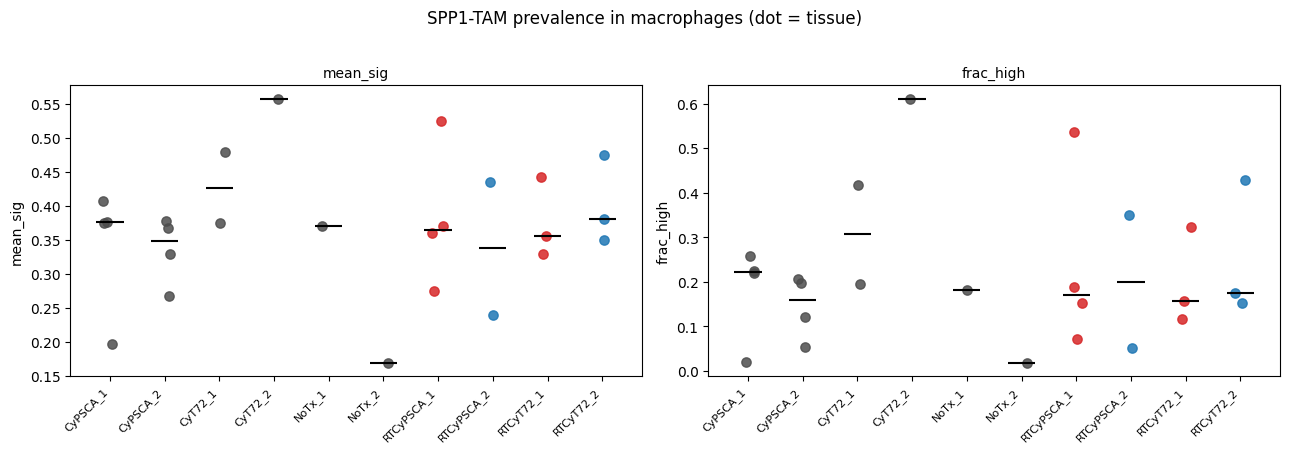

In [5]:
mac_all = adata.obs.loc[adata.obs["is_mac"]]
global_cut = float(mac_all["SPP1_TAM_sig"].quantile(0.75))

rows = []
for t, sub in adata.obs.groupby(adata.obs[TISSUE_COL].astype(str), observed=True):
    macs = sub[sub["is_mac"]]
    if len(macs) < MIN_MACS_PER_TISSUE:
        print(f"skip {t}: {len(macs)} macs (< {MIN_MACS_PER_TISSUE})"); continue
    meta = tissue_meta.loc[t]
    rows.append({"tissue": t, "cond": meta["cond"], "tumor_loc": meta["tumor_loc"],
                 "group": meta["group"], "rt_group": meta["rt_group"],
                 "n_mac": len(macs), "mean_sig": float(macs["SPP1_TAM_sig"].mean()),
                 "median_sig": float(macs["SPP1_TAM_sig"].median()),
                 "frac_high": float((macs["SPP1_TAM_sig"] >= global_cut).mean())})
prev = pd.DataFrame(rows)
prev.to_csv(OUT_DIR / "spp1tam_prevalence_per_tissue.csv", index=False)

print("\n--- prevalence by group (mean of tissue values) ---")
print(prev.groupby("group", observed=True)[["n_mac", "mean_sig", "frac_high"]].mean().round(3).to_string())

colors = {"no_RT": "#4d4d4d", "RT_direct": "#d62728", "RT_abscopal": "#1f77b4"}
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
xmap = {g: i for i, g in enumerate(GROUP_ORDER)}
for ax, metric in zip(axes, ["mean_sig", "frac_high"]):
    for g in GROUP_ORDER:
        s = prev[prev["group"] == g]
        v = s[metric].dropna().values
        ax.scatter(xmap[g] + rng.uniform(-0.12, 0.12, len(v)), v, s=45,
                   color=colors.get(s["rt_group"].iloc[0] if len(s) else "no_RT", "k"), alpha=0.85)
        if len(v):
            ax.hlines(np.median(v), xmap[g] - 0.25, xmap[g] + 0.25, color="k", lw=1.5)
    ax.set_xticks(list(xmap.values())); ax.set_xticklabels(GROUP_ORDER, rotation=45, ha="right", fontsize=8)
    ax.set_title(metric, fontsize=10); ax.set_ylabel(metric)
fig.suptitle("SPP1-TAM prevalence in macrophages (dot = tissue)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_prevalence.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. Engine: local niche around each macrophage (from non-myeloid cells)

In [6]:
def coords_um_for(tname):
    mask = adata.obs[TISSUE_COL].astype(str).eq(tname).values
    coords = np.asarray(adata.obsm["spatial"][mask], float)
    scale = 1.0
    if APPLY_HIRES_SCALE and get_transformation is not None:
        k = f"{tname}_cell_boundaries"
        if k in sdata.shapes:
            try:
                scale = float(get_transformation(sdata.shapes[k], get_all=True)["downscale_to_hires"].scale[0])
            except Exception:
                pass
    return mask, coords * scale * MICRONS_PER_PIXEL

def local_niche(coords_all, mac_idx, niche_col_mask, score_matrix, radius=NEIGHBOR_RADIUS_UM):
    """For each macrophage, mean of each pathway score over NICHE cells within `radius`.
    Returns (n_mac, n_path) and the neighbour count per mac."""
    nn = NearestNeighbors(radius=radius).fit(coords_all)
    G = nn.radius_neighbors_graph(coords_all[mac_idx], mode="connectivity")   # (n_mac, n_all)
    keep = sp.diags(niche_col_mask.astype(float))
    G = G @ keep                                                              # zero out non-niche columns
    counts = np.asarray(G.sum(1)).ravel()
    niche = np.asarray(G @ score_matrix)                                      # (n_mac, n_path) sums
    with np.errstate(invalid="ignore", divide="ignore"):
        niche = niche / counts[:, None]
    return niche, counts

print("engine ready")

engine ready


## 6. Pathway panel (the niche mechanism) + scoring

In [7]:
PANEL = {
    "Hypoxia_Hallmark": ("HALLMARK_HYPOXIA", "niche"),
    "Hypoxia_Response_GO": ("GOBP_CELLULAR_RESPONSE_TO_HYPOXIA", "niche"),
    "Adenosine_Metab_GO": ("GOBP_ADENOSINE_METABOLIC_PROCESS", "niche"),
    "AMP_Metab_GO": ("GOBP_AMP_METABOLIC_PROCESS", "niche"),
    "oxLDL_Response_GO": ("GOBP_CELLULAR_RESPONSE_TO_OXIDISED_LOW_DENSITY_LIPOPROTEIN_PARTICLE_STIMULUS", "niche"),
    "Lipid_Oxidation_GO": ("GOBP_LIPID_OXIDATION", "niche"),
    "Scavenger_Reactome": ("REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS", "niche"),
    "Cholesterol_Homeo_Hallmark": ("HALLMARK_CHOLESTEROL_HOMEOSTASIS", "niche"),
    "Glycolysis_Hallmark": ("HALLMARK_GLYCOLYSIS", "niche"),
    "Lactate_Metab_GO": ("GOBP_LACTATE_METABOLIC_PROCESS", "niche"),
    "FoamCell_Mac_GO": ("GOBP_MACROPHAGE_DERIVED_FOAM_CELL_DIFFERENTIATION", "niche"),
    "ECM_Reactome": ("REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION", "amplifier"),
    "Angiogenesis_Hallmark": ("HALLMARK_ANGIOGENESIS", "amplifier"),
    "Apoptosis_Hallmark": ("HALLMARK_APOPTOSIS", "contrast"),
    "IFN_gamma_Hallmark": ("HALLMARK_INTERFERON_GAMMA_RESPONSE", "contrast"),
    "P53_Hallmark": ("HALLMARK_P53_PATHWAY", "contrast"),
}
TIER_OF = {k: v[1] for k, v in PANEL.items()}

def read_gmt(p):
    out = {}
    for line in open(p):
        x = line.rstrip("\n").split("\t")
        if len(x) >= 3: out[x[0]] = x[2:]
    return out
gene_sets = {}
for _, p in GMT_FILES.items():
    gene_sets.update(read_gmt(p))

available = set(adata.var_names.astype(str))
niche_cols = []
for short, (gs, _) in PANEL.items():
    matched = [g for g in gene_sets.get(gs, []) if g in available]
    if len(matched) < MIN_MATCHED_GENES:
        print(f"[skip] {short}: {len(matched)} genes"); continue
    sc.tl.score_genes(adata, gene_list=matched, score_name=f"{short}_score", use_raw=False, random_state=0)
    niche_cols.append(short)
print(f"{len(niche_cols)}/{len(PANEL)} niche pathways scored")

16/16 niche pathways scored


In [8]:
rows = []
for short, (gs, tier) in PANEL.items():
    matched = [g for g in gene_sets.get(gs, []) if g in available]
    if not matched:
        continue
    X = adata[:, matched].X
    det = np.asarray((X > 0).mean(axis=0)).ravel()        # per-gene detection rate
    s = adata.obs.get(f"{short}_score")
    rows.append({"pathway": short, "tier": tier,
                 "n_in_set": len(gene_sets.get(gs, [])), "n_matched": len(matched),
                 "mean_detection_pct": 100 * float(det.mean()),
                 "genes_det_gt10pct": int((det > 0.10).sum()),
                 "score_IQR": float(np.subtract(*np.percentile(s, [75, 25]))) if s is not None else np.nan})
qc = pd.DataFrame(rows).sort_values("mean_detection_pct", ascending=False)
qc.to_csv(OUT_DIR / "pathway_detection_qc.csv", index=False)
print(qc.round(2).to_string(index=False))
print("\nPathways with few matched genes / low detection / small score_IQR are UNDERPOWERED —")
print("a null there is uninformative and must not be reported as a negative finding.")


                   pathway      tier  n_in_set  n_matched  mean_detection_pct  genes_det_gt10pct  score_IQR
     Angiogenesis_Hallmark amplifier        36         36               15.94                 15       0.22
        Apoptosis_Hallmark  contrast       161        158               13.06                 66       0.15
Cholesterol_Homeo_Hallmark     niche        71         70               11.70                 23       0.16
        IFN_gamma_Hallmark  contrast       188        180               11.30                 70       0.22
              ECM_Reactome amplifier       264        257               11.10                 80       0.12
              P53_Hallmark  contrast       200        188               10.41                 65       0.11
              AMP_Metab_GO     niche        28         24                9.67                  9       0.20
          Hypoxia_Hallmark     niche       199        195                9.65                 70       0.10
       Hypoxia_Response_GO  

## 7. Q3 — Do high-signature macs sit in the niche? (per tissue x pathway correlation)

For each tissue: build the local niche (from non-myeloid cells) around every macrophage, then
**Spearman(SPP1_TAM_sig, local niche score)** across macs. Positive ρ = macs carrying more
SPP1-TAM program sit in stronger niche neighbourhoods.

In [10]:
tissues = [t for t in tissues_all if (TISSUE_SUBSET is None or t in TISSUE_SUBSET)]
score_cols_full = [f"{c}_score" for c in niche_cols]

rows = []
for ti, tname in enumerate(tissues, 1):
    mask, coords = coords_um_for(tname)
    if mask.sum() < MIN_CELLS:
        continue
    obs_t = adata.obs.loc[mask]
    mac_local = obs_t["is_mac"].values
    if mac_local.sum() < MIN_MACS_PER_TISSUE:
        print(f"skip {tname}: {int(mac_local.sum())} macs"); continue
    niche_local = obs_t["niche_cell"].values
    score_mat = obs_t[score_cols_full].to_numpy(float)          # (n_all, n_path)
    sig_mac = obs_t.loc[mac_local, "SPP1_TAM_sig"].to_numpy(float)
    mac_idx = np.where(mac_local)[0]

    niche_vals, ncount = local_niche(coords, mac_idx, niche_local, score_mat)
    ok = ncount >= 3                                            # macs with a real neighbourhood
    cond, loc, rep = parse_tissue(tname)
    for j, short in enumerate(niche_cols):
        v = niche_vals[ok, j]; s = sig_mac[ok]
        good = np.isfinite(v) & np.isfinite(s)
        if good.sum() < MIN_MACS_PER_TISSUE or np.nanstd(v[good]) == 0:
            continue
        rho, p = spearmanr(s[good], v[good])
        rows.append({"tissue": tname, "cond": cond, "tumor_loc": loc,
                     "rt_group": rt_group_of(cond, loc), "group": f"{cond}_{loc}",
                     "pathway": short, "tier": TIER_OF[short], "n_mac": int(good.sum()),
                     "rho": rho, "p": p})
    print(f"[{ti}/{len(tissues)}] {tname} macs={int(mac_local.sum())} done", flush=True)

niche_corr = pd.DataFrame(rows)
niche_corr.to_csv(OUT_DIR / "spp1tam_niche_correlation_long.csv", index=False)
print("\nniche_corr:", niche_corr.shape)

[1/32] CyPSCA_1_1 macs=1914 done
[2/32] CyPSCA_1_2 macs=1148 done
[3/32] CyPSCA_1_3 macs=3740 done
[4/32] CyPSCA_1_4 macs=1337 done
[5/32] CyPSCA_2_1 macs=4134 done
[6/32] CyPSCA_2_2 macs=2163 done
[7/32] CyPSCA_2_3 macs=3029 done
[8/32] CyPSCA_2_4 macs=2836 done
[9/32] CyT72_1_2 macs=4102 done
[10/32] CyT72_1_4 macs=4471 done
[11/32] CyT72_2_3 macs=6168 done
skip CyT72_2_4: 12 macs
[13/32] NoTx_1_1 macs=586 done
skip NoTx_1_2: 4 macs
skip NoTx_1_3: 11 macs
skip NoTx_1_4: 20 macs
skip NoTx_2_1: 3 macs
skip NoTx_2_2: 44 macs
[19/32] NoTx_2_3 macs=57 done
skip NoTx_2_4: 7 macs
[21/32] RTCyPSCA_1_2 macs=625 done
[22/32] RTCyPSCA_1_3 macs=2791 done
[23/32] RTCyPSCA_1_4 macs=3012 done
[24/32] RTCyPSCA_1_5 macs=557 done
[25/32] RTCyPSCA_2_3 macs=6693 done
[26/32] RTCyPSCA_2_4 macs=2503 done
[27/32] RTCyT72_1_1 macs=2614 done
[28/32] RTCyT72_1_2 macs=6926 done
[29/32] RTCyT72_1_4 macs=1997 done
[30/32] RTCyT72_2_1 macs=6537 done
[31/32] RTCyT72_2_2 macs=4939 done
[32/32] RTCyT72_2_4 macs=6585

## 8. Summary: which niches hold the SPP1-TAM program?

=== SPP1-TAM signature vs local niche (mean Spearman rho across tissues) ===
   niche built from NON-myeloid cells; contrast-tier should stay near 0

     tier                    pathway  n_tissues  mean_rho  frac_pos
amplifier               ECM_Reactome         25     0.115      0.92
amplifier      Angiogenesis_Hallmark         25     0.109      0.88
 contrast         Apoptosis_Hallmark         25     0.093      0.76
 contrast               P53_Hallmark         25     0.070      0.72
 contrast         IFN_gamma_Hallmark         25    -0.111      0.36
    niche        Hypoxia_Response_GO         25     0.086      0.76
    niche           Hypoxia_Hallmark         25     0.076      0.92
    niche        Glycolysis_Hallmark         25     0.072      0.76
    niche Cholesterol_Homeo_Hallmark         25     0.065      0.68
    niche         Lipid_Oxidation_GO         25     0.054      0.72
    niche         Scavenger_Reactome         25     0.037      0.76
    niche               AMP_Metab_

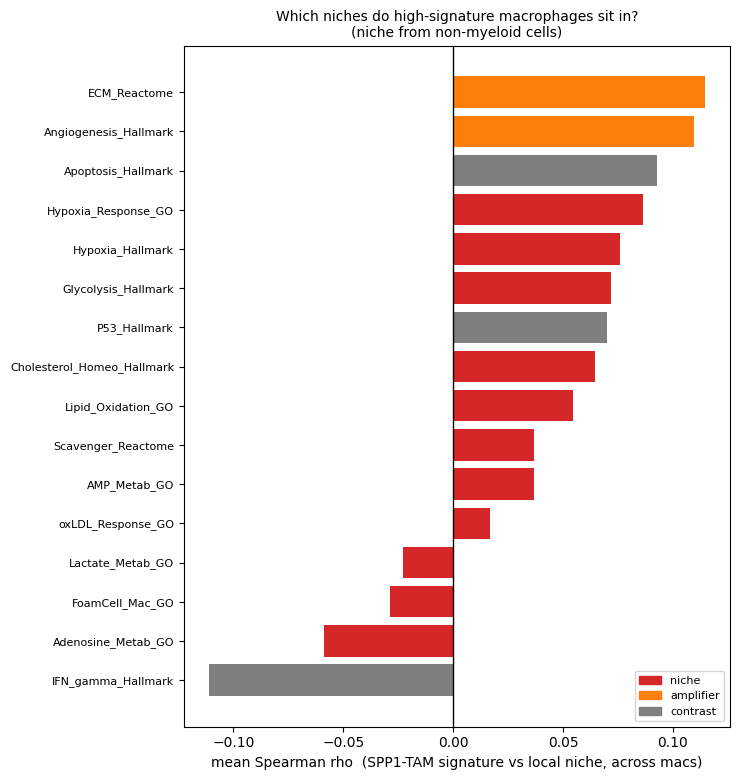

In [11]:
summ = (niche_corr.groupby(["tier", "pathway"], observed=True)
        .agg(n_tissues=("tissue", "count"), mean_rho=("rho", "mean"),
             frac_pos=("rho", lambda s: (s > 0).mean()))
        .reset_index().sort_values(["tier", "mean_rho"], ascending=[True, False]))
summ.to_csv(OUT_DIR / "spp1tam_niche_correlation_summary.csv", index=False)
print("=== SPP1-TAM signature vs local niche (mean Spearman rho across tissues) ===")
print("   niche built from NON-myeloid cells; contrast-tier should stay near 0\n")
print(summ.round(3).to_string(index=False))

plot = summ.sort_values("mean_rho")
tier_c = {"niche": "#d62728", "amplifier": "#ff7f0e", "contrast": "#7f7f7f"}
fig, ax = plt.subplots(figsize=(7.5, 0.4 * len(plot) + 1.5))
ax.barh(range(len(plot)), plot["mean_rho"].values, color=[tier_c[t] for t in plot["tier"]])
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot["pathway"], fontsize=8)
ax.set_xlabel("mean Spearman rho  (SPP1-TAM signature vs local niche, across macs)")
ax.set_title("Which niches do high-signature macrophages sit in?\n(niche from non-myeloid cells)", fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=t) for t, c in tier_c.items()], fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_niche_correlation.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 9. Does the niche coupling change with RT?

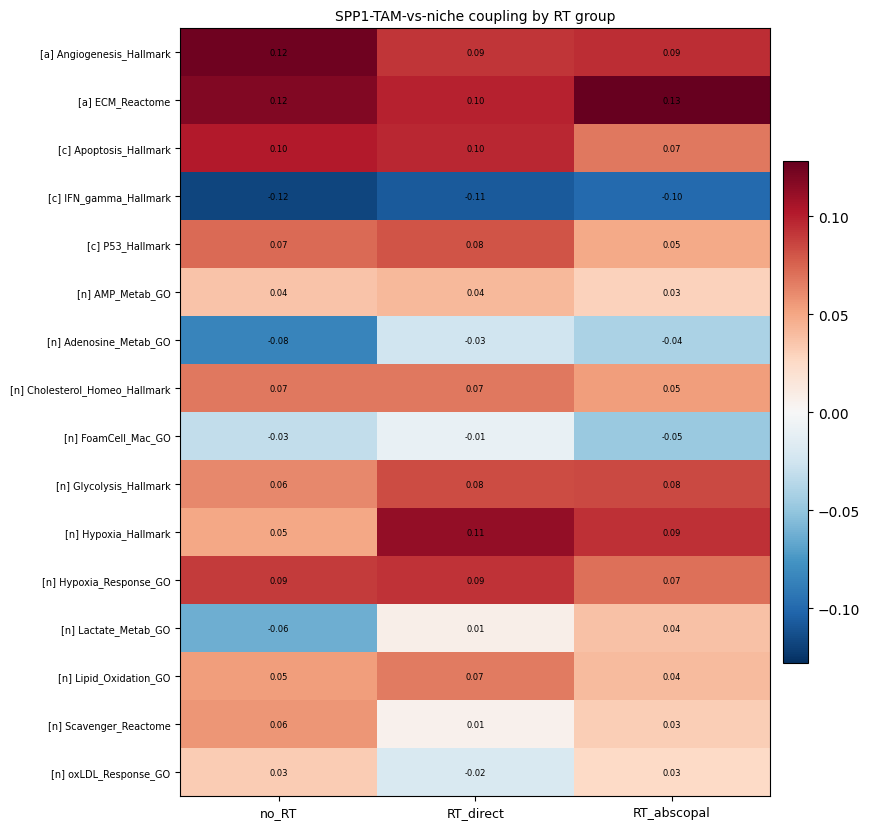

In [12]:
piv = (niche_corr.groupby(["tier", "pathway", "rt_group"], observed=True)["rho"]
       .mean().unstack("rt_group"))
piv = piv.reindex(columns=[c for c in ["no_RT", "RT_direct", "RT_abscopal"] if c in piv.columns])
piv.to_csv(OUT_DIR / "spp1tam_niche_correlation_by_rt.csv")
data = piv.values.astype(float); vmax = np.nanmax(np.abs(data)) or 1.0
fig, ax = plt.subplots(figsize=(1.6 * data.shape[1] + 4, 0.4 * data.shape[0] + 2))
im = ax.imshow(data, cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(piv.columns, fontsize=9)
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels([f"[{t[0][0]}] {t[1]}" for t in piv.index], fontsize=7)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isfinite(data[i, j]):
            ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=6)
ax.set_title("SPP1-TAM-vs-niche coupling by RT group", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_niche_by_rt.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 10. Localization maps — where the SPP1-TAM macs are (focus tissues)

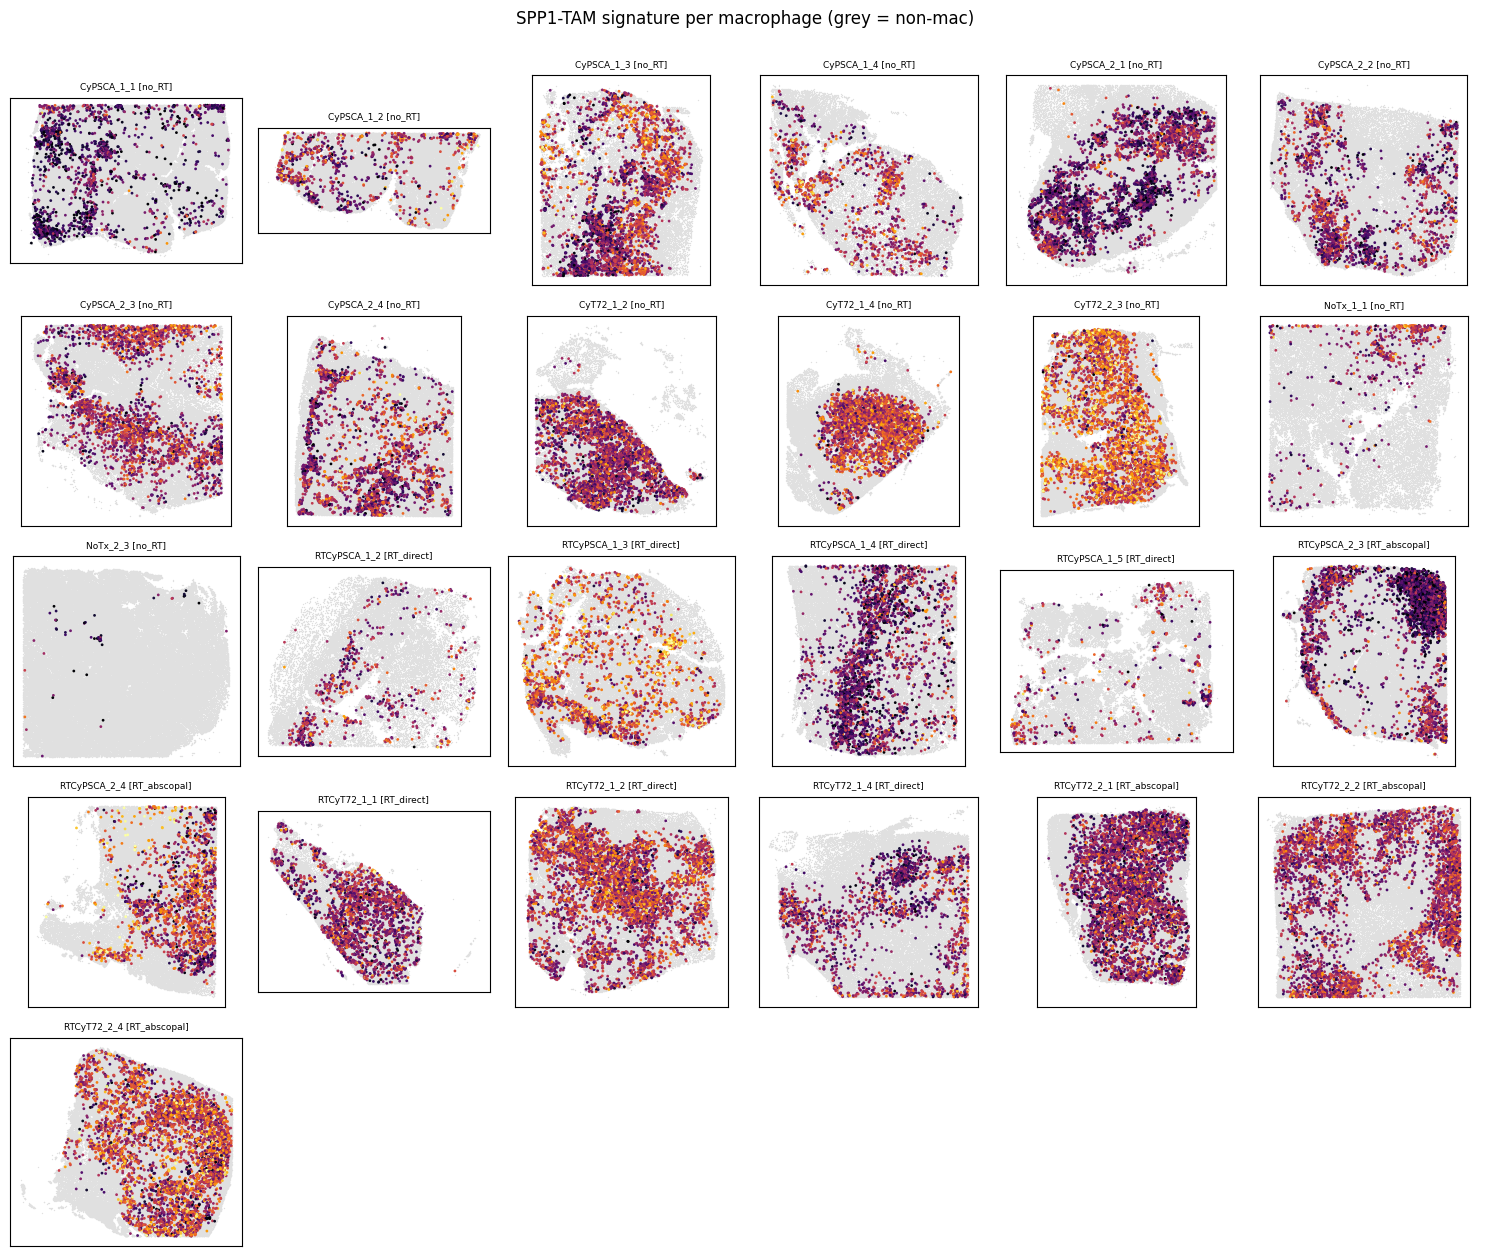

In [13]:
def _ordered_tissues():
    d = prev.copy()
    return d.sort_values(["group", "tissue"])["tissue"].tolist()

def tam_map(tlist, ncols=6):
    tlist = [t for t in tlist if adata.obs[TISSUE_COL].astype(str).eq(t).sum() >= MIN_CELLS]
    nrows = int(np.ceil(len(tlist) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows), squeeze=False)
    sig_all = adata.obs.loc[adata.obs["is_mac"], "SPP1_TAM_sig"]
    vmax = float(np.nanpercentile(sig_all, 99)); vmin = float(np.nanpercentile(sig_all, 1))
    for ax, t in zip(axes.ravel(), tlist):
        mask, coords = coords_um_for(t)
        obs_t = adata.obs.loc[mask]; mac = obs_t["is_mac"].values
        ax.scatter(coords[~mac, 0], coords[~mac, 1], s=1, color="0.88", linewidths=0, rasterized=True)
        sctt = ax.scatter(coords[mac, 0], coords[mac, 1], c=obs_t.loc[mac, "SPP1_TAM_sig"],
                          cmap="inferno", vmin=vmin, vmax=vmax, s=4, linewidths=0, rasterized=True)
        ax.set_title(f"{t} [{tissue_meta.loc[t,'rt_group']}]", fontsize=6.5)
        ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])
    for ax in axes.ravel()[len(tlist):]:
        ax.axis("off")
    fig.suptitle("SPP1-TAM signature per macrophage (grey = non-mac)", y=1.002, fontsize=12)
    fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_maps.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

tam_map(_ordered_tissues())

## 11. Summary

In [15]:
print(f"""
==================== SUMMARY — report these back ====================
Signature genes used : {len(present)}  (from {SIG_CSV.name}; RELAXED in 01c §5)
Tissues analyzed     : {niche_corr['tissue'].nunique()} | macs/tissue >= {MIN_MACS_PER_TISSUE}
Niche radius         : {NEIGHBOR_RADIUS_UM} um | niche from NON-myeloid cells

Top niches (SPP1-TAM signature vs local niche, mean rho):
{summ.nlargest(5, 'mean_rho')[['pathway','tier','mean_rho','frac_pos']].round(3).to_string(index=False)}

READ
 - mean_rho > 0 & frac_pos >= 0.7  -> high-signature macs consistently sit in that niche.
 - CONTRAST tier (IFN/p53/apoptosis) should stay near 0. If it rises with the niche tier,
   the coupling is non-specific (density), not niche-selective - discount accordingly.
 - Prevalence (Q1) answers "which conditions have more SPP1-TAM macs"; niche (Q3) answers
   "what environment they sit in"; maps (10) show it cell-by-cell.

This is LOCALIZATION. The metabolic-state claim rests on the single-cell DE (01c/01d), not
on this signature (which was stripped of lipid genes for spatial specificity, then RELAXED).
=====================================================================
""")


==================== SUMMARY — report these back ====================
Signature genes used : 48  (from sc_spp1_tam_signature.csv; RELAXED in 01c §5)
Tissues analyzed     : 25 | macs/tissue >= 50
Niche radius         : 50 um | niche from NON-myeloid cells

Top niches (SPP1-TAM signature vs local niche, mean rho):
              pathway      tier  mean_rho  frac_pos
         ECM_Reactome amplifier     0.115      0.92
Angiogenesis_Hallmark amplifier     0.109      0.88
   Apoptosis_Hallmark  contrast     0.093      0.76
  Hypoxia_Response_GO     niche     0.086      0.76
     Hypoxia_Hallmark     niche     0.076      0.92

READ
 - mean_rho > 0 & frac_pos >= 0.7  -> high-signature macs consistently sit in that niche.
 - CONTRAST tier (IFN/p53/apoptosis) should stay near 0. If it rises with the niche tier,
   the coupling is non-specific (density), not niche-selective - discount accordingly.
 - Prevalence (Q1) answers "which conditions have more SPP1-TAM macs"; niche (Q3) answers
   "what e